In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../cosmetics_raw.csv")
df.head()


,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [38]:
print("Shape:", df.shape) # Display the shape of the df
display(df.sample(5, random_state=42))

print("\nDtypes:") # Display the data types 
print(df.dtypes)

print("\nColumns:") # Display the column names
print(list(df.columns))


Shape: (1472, 11)


,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
852,Face Mask,SK-II,Overnight Miracle Mask,105,3.8,"Galactomyces Ferment Filtrate*, Water, Glyceri...",1,1,1,1,1
184,Moisturizer,ESTÉE LAUDER,Advanced Time Zone Night Age Reversing Line/Wr...,80,4.7,Adv Timezone Night Age Rvr Lw Crm Division: El...,0,0,0,0,0
1261,Eye cream,PETER THOMAS ROTH,FIRMx™ 360 Eye Renewal,75,4.0,-Nutrex EGF -Epidermosil™ -Eye Regener™ -Diamo...,1,1,1,1,0
67,Moisturizer,SMASHBOX,Camera Ready BB Cream SPF 35,42,4.0,"Water, Dimethicone, Butylene Glycol, Phenyl Tr...",0,0,0,0,0
220,Moisturizer,CLINIQUE,Moisture Surge Overnight Mask,35,4.5,"Water , Glycerin , Cetyl Alcohol , Dimethicone...",0,0,0,0,0



Dtypes:
Label              str
Brand              str
Name               str
Price            int64
Rank           float64
Ingredients        str
Combination      int64
Dry              int64
Normal           int64
Oily             int64
Sensitive        int64
dtype: object

Columns:
['Label', 'Brand', 'Name', 'Price', 'Rank', 'Ingredients', 'Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']


In [39]:
missing = df.isna().sum().sort_values(ascending=False) # Looking for missing values
missing_pct = (missing / len(df) * 100).round(2)

summary_missing = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(summary_missing[summary_missing["missing_count"] > 0])

print("Duplicate rows:", df.duplicated().sum())


,missing_count,missing_pct


Duplicate rows: 0


In [40]:
# DSummary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Price,1472.0,55.584239,45.014429,3.0,30.0,42.5,68.0,370.0
Rank,1472.0,4.153261,0.633918,0.0,4.0,4.3,4.5,5.0
Combination,1472.0,0.656250,0.475120,0.0,0.0,1.0,1.0,1.0
Dry,1472.0,0.614130,0.486965,0.0,0.0,1.0,1.0,1.0
Normal,1472.0,0.652174,0.476442,0.0,0.0,1.0,1.0,1.0
Oily,1472.0,0.607337,0.488509,0.0,0.0,1.0,1.0,1.0
Sensitive,1472.0,0.513587,0.499985,0.0,0.0,1.0,1.0,1.0


,count,pct
Label,,
Moisturizer,298,20.24
Cleanser,281,19.09
Face Mask,266,18.07
Treatment,248,16.85
Eye cream,209,14.20
Sun protect,170,11.55


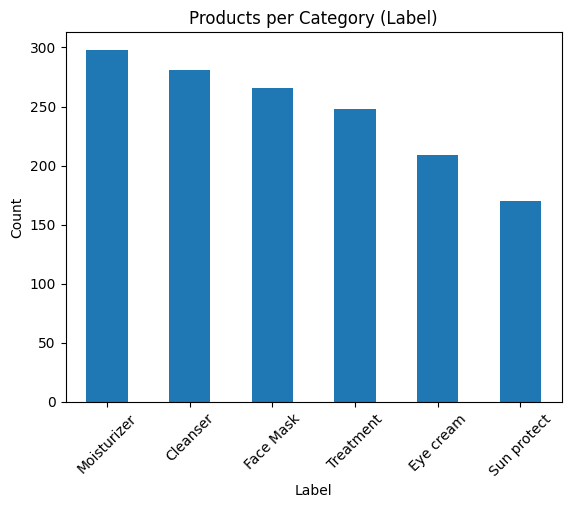

In [41]:
# Distribution of products per (Label) category
label_counts = df["Label"].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)

label_dist = pd.DataFrame({"count": label_counts, "pct": label_pct})
display(label_dist)

label_counts.plot(kind="bar")
plt.title("Products per Category (Label)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


Brand
CLINIQUE              79
SEPHORA COLLECTION    66
SHISEIDO              63
ORIGINS               54
MURAD                 47
KIEHL'S SINCE 1851    46
PETER THOMAS ROTH     46
FRESH                 44
DR. JART+             41
KATE SOMERVILLE       35
LANCÔME               34
ESTÉE LAUDER          32
LA MER                30
CAUDALIE              30
PERRICONE MD          30
PHILOSOPHY            29
FIRST AID BEAUTY      28
OLEHENRIKSEN          27
ALGENIST              27
DIOR                  27
Name: count, dtype: int64

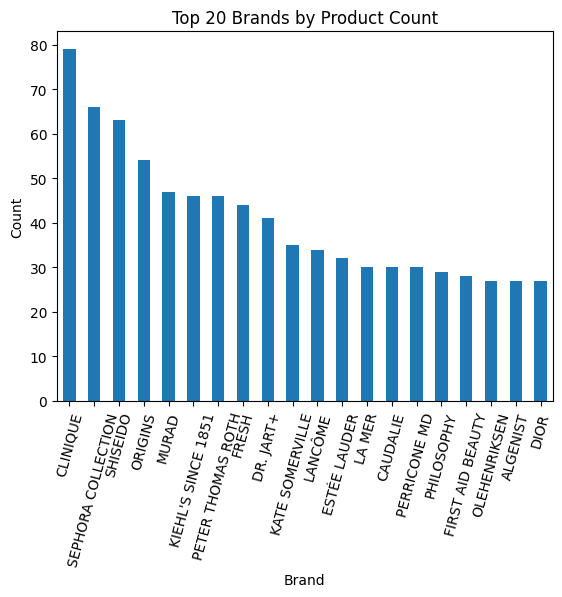

In [42]:
# Distribution of products per Brand
brand_counts = df["Brand"].value_counts().head(20)
display(brand_counts)

brand_counts.plot(kind="bar")
plt.title("Top 20 Brands by Product Count")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()


The dataset shows a concentration of products within a small number of major brands, with Clinique, Sephora Collection, and Shiseido having the highest product counts, while many other brands contribute fewer items. This imbalance suggests that the recommender system may naturally favor larger brands unless additional normalization or diversity mechanisms are applied to prevent popularity bias. (which is why we later consider this class imbalance)

Price summary:


count    1472.000000
mean       55.584239
std        45.014429
min         3.000000
25%        30.000000
50%        42.500000
75%        68.000000
max       370.000000
Name: Price, dtype: float64

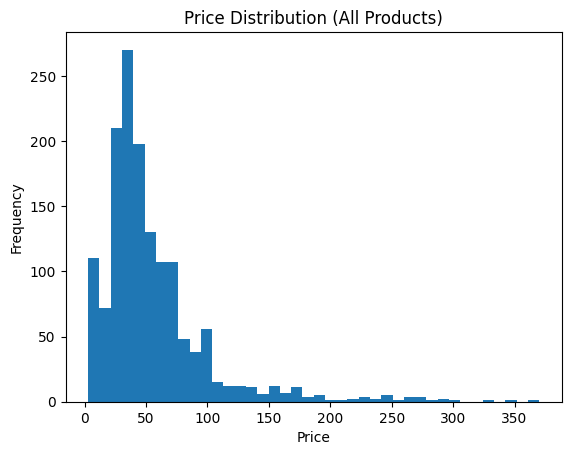

In [43]:
# Price distribution
print("Price summary:")
display(df["Price"].describe())

df["Price"].plot(kind="hist", bins=40)
plt.title("Price Distribution (All Products)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


The price distribution is right-skewed, with most products concentrated in the lower to mid-price range (median of 42.50), while a smaller number of premium products extend the maximum price up to 370. This indicates that price is a meaningful differentiating feature and supports the need for price-based filtering and dupe-finding functionality to help users discover more affordable alternatives.

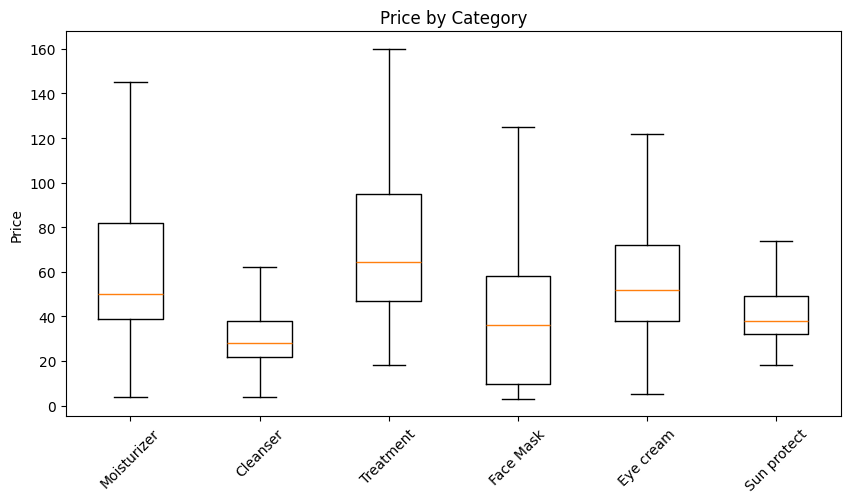

In [44]:
# Price by Label 
labels = df["Label"].unique().tolist()

data_by_label = [df.loc[df["Label"] == lab, "Price"].dropna().values for lab in labels]

plt.figure(figsize=(10, 5))
plt.boxplot(data_by_label, tick_labels=labels, showfliers=False)
plt.title("Price by Category")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()


Treatment and eye cream products exhibit the highest median prices and the greatest variability, indicating that these categories tend to include more premium and specialized formulations. In contrast, cleansers and sun protection products have lower and more consistent price ranges, suggesting they are generally more affordable and standardized across brands.

Rank summary:


count    1472.000000
mean        4.153261
std         0.633918
min         0.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rank, dtype: float64

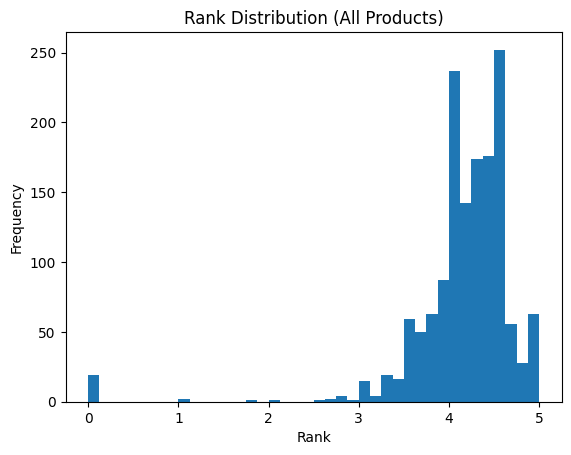

Label
Cleanser       4.4
Face Mask      4.3
Moisturizer    4.3
Treatment      4.3
Sun protect    4.1
Eye cream      3.9
Name: Rank, dtype: float64

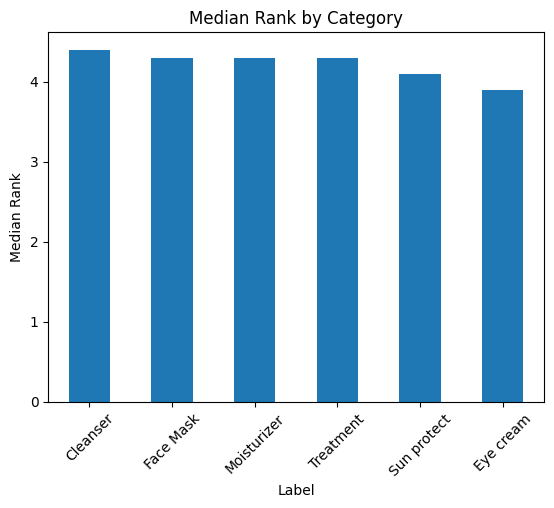

In [45]:
# Rank distribution
print("Rank summary:")
display(df["Rank"].describe())

df["Rank"].plot(kind="hist", bins=40)
plt.title("Rank Distribution (All Products)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()

# Rank by label: medians
rank_median_by_label = df.groupby("Label")["Rank"].median().sort_values(ascending=False)
display(rank_median_by_label)

rank_median_by_label.plot(kind="bar")
plt.title("Median Rank by Category")
plt.xlabel("Label")
plt.ylabel("Median Rank")
plt.xticks(rotation=45)
plt.show()


The rank distribution is heavily concentrated between 4.0 and 5.0, indicating that most products in the dataset are highly rated and generally well-reviewed. This limited variability suggests that rank alone may not strongly differentiate products, reinforcing the importance of ingredient-based features and personalized preference modeling in the recommender system.

Combination [np.int64(0), np.int64(1)]
Dry [np.int64(0), np.int64(1)]
Normal [np.int64(0), np.int64(1)]
Oily [np.int64(0), np.int64(1)]
Sensitive [np.int64(0), np.int64(1)]


Combination    966
Normal         960
Dry            904
Oily           894
Sensitive      756
dtype: int64

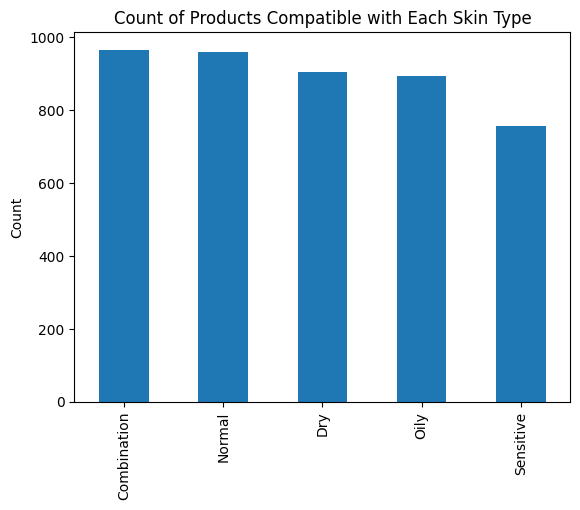

In [46]:
skin_cols = ["Combination", "Dry", "Normal", "Oily", "Sensitive"]

# sanity check values
for c in skin_cols:
    print(c, sorted(df[c].dropna().unique())[:10])

skin_counts = df[skin_cols].sum().sort_values(ascending=False)
display(skin_counts)

skin_counts.plot(kind="bar")
plt.title("Count of Products Compatible with Each Skin Type")
plt.ylabel("Count")
plt.show()


The dataset contains a relatively balanced number of products compatible with combination, normal, dry, and oily skin types, while fewer products are explicitly marked as suitable for sensitive skin. This indicates that sensitive skin users may have more limited options, highlighting the importance of incorporating skin type compatibility as a key constraint in the recommendation process.

skin_type_count
0    471
1      7
2     48
3     69
4    215
5    662
Name: count, dtype: int64

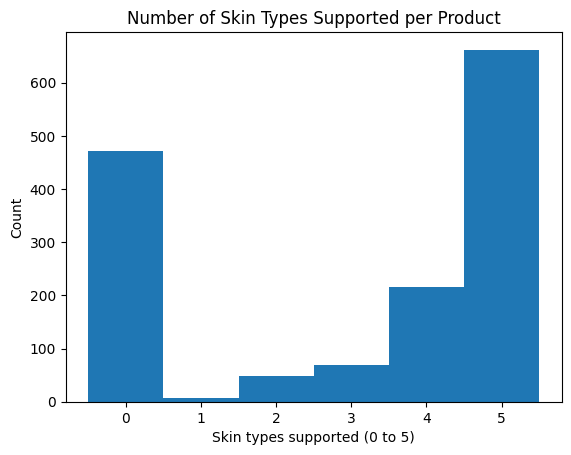

In [47]:
# Count how many skin types each product supports
df["skin_type_count"] = df[skin_cols].sum(axis=1)

display(df["skin_type_count"].value_counts().sort_index())

df["skin_type_count"].plot(kind="hist", bins=np.arange(-0.5, 6.5, 1))
plt.title("Number of Skin Types Supported per Product")
plt.xlabel("Skin types supported (0 to 5)")
plt.ylabel("Count")
plt.show()


Most products in the dataset support multiple skin types, with a large concentration of products compatible with four or five skin types, indicating that many formulations are designed to be broadly applicable. However, the presence of products supporting fewer or no skin types suggests variability in specialization, reinforcing the need for skin type–based filtering to ensure relevant and personalized recommendations.

In [48]:
# Products with missing/zero price
print("Price <= 0:", (df["Price"] <= 0).sum())
print("Missing Price:", df["Price"].isna().sum())

# Empty ingredient lists
empty_ing = df["Ingredients"].fillna("").str.strip().eq("")
print("Empty Ingredients:", empty_ing.sum())

# Skin types where none are 1
none_skin = (df[skin_cols].sum(axis=1) == 0).sum()
print("No skin type marked compatible:", none_skin)


Price <= 0: 0
Missing Price: 0
Empty Ingredients: 0
No skin type marked compatible: 471


The dataset contains no missing or zero values for price or ingredients, indicating a high level of completeness and reliability for key recommendation features. However, 471 products are not marked as compatible with any skin type, which we will need to take into account and  highlights the need for careful handling or filtering of these products during recommendation generation.